# Iris Flower Classification
CodeAlpha Data Science Internship

This notebook classifies Iris flowers (setosa, versicolor, virginica) based on petal and sepal measurements, using several classification models.

## 1. Load and Explore the Dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
df.info()
print()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [3]:
# Check for missing values and class balance
print("Missing values:\n", df.isnull().sum())
print("\nClass balance:\n", df['species'].value_counts())

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Class balance:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 2. Data Visualization

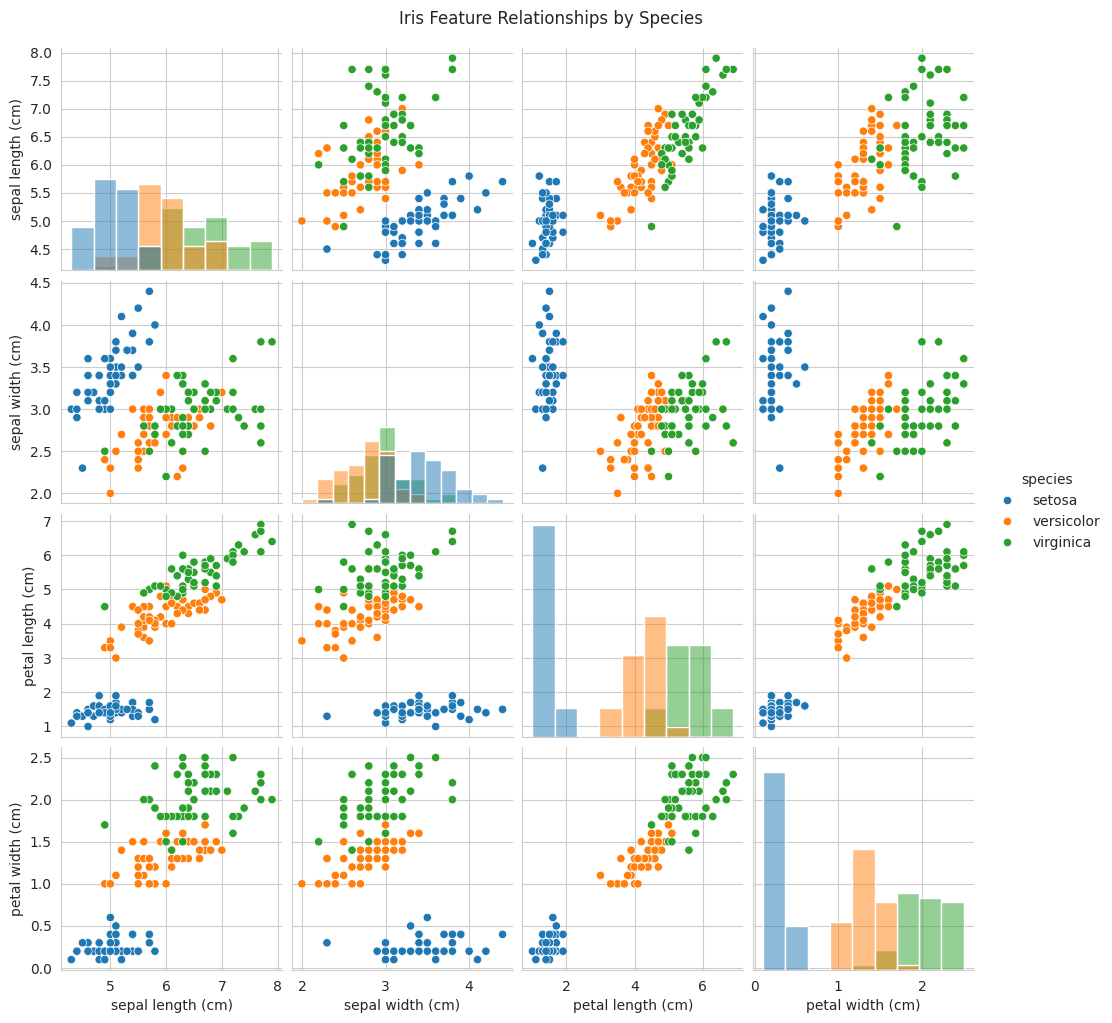

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pairplot = sns.pairplot(df, hue='species', diag_kind='hist')
pairplot.fig.suptitle("Iris Feature Relationships by Species", y=1.02)
plt.show()

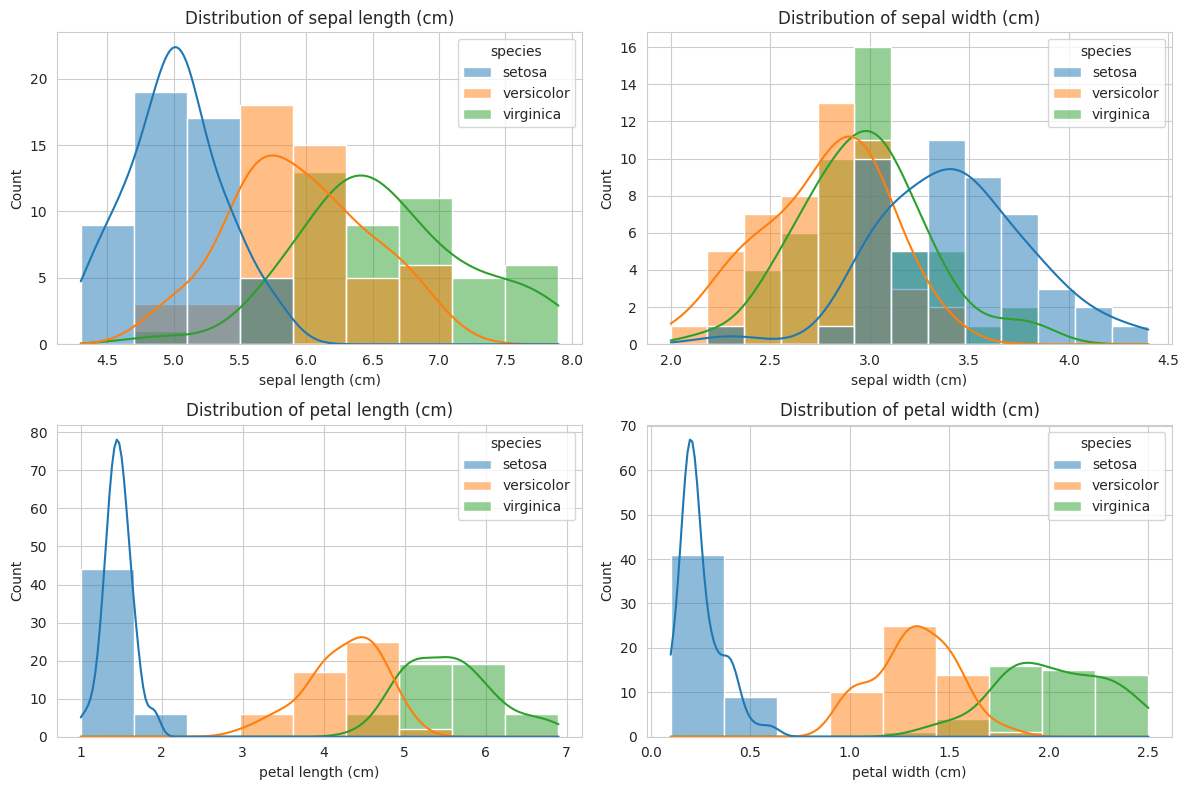

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), iris.feature_names):
    sns.histplot(data=df, x=col, hue='species', kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## 3. Correlation Heatmap

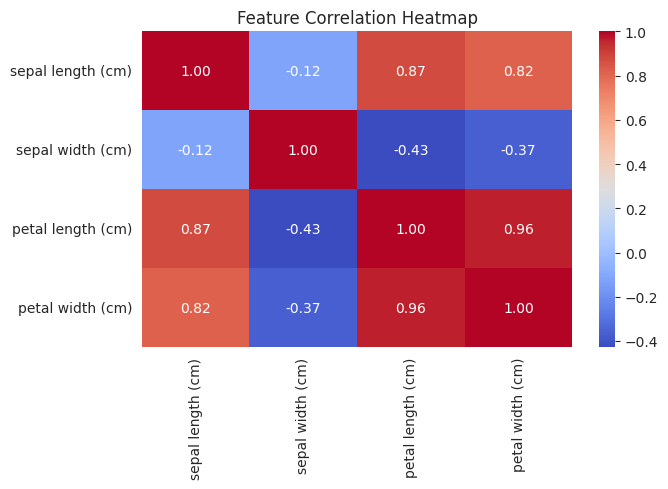

In [6]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150)
plt.show()

## 4. Train/Test Split

In [7]:
from sklearn.model_selection import train_test_split

X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (120, 4)
Test shape: (30, 4)


## 5. Baseline Model: Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")

Logistic Regression Accuracy: 0.9667


## 6. K-Nearest Neighbors Classifier

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {acc_knn:.4f}")

KNN Accuracy: 1.0000


## 7. Decision Tree Classifier

In [10]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {acc_dt:.4f}")

Decision Tree Accuracy: 0.9333


In [11]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree'],
    'Accuracy': [acc_lr, acc_knn, acc_dt]
}).sort_values('Accuracy', ascending=False)

results

,Model,Accuracy
1,KNN,1.000000
0,Logistic Regression,0.966667
2,Decision Tree,0.933333


## 8. Detailed Evaluation of Best Model

Best model: KNN

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



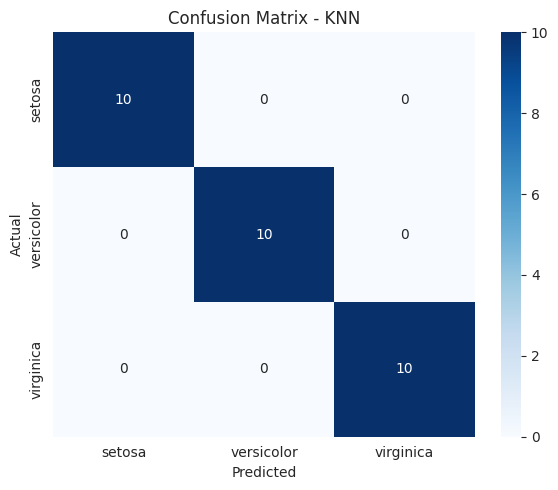

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

best_model_name = results.iloc[0]['Model']
best_preds = {'Logistic Regression': y_pred_lr, 'KNN': y_pred_knn, 'Decision Tree': y_pred_dt}[best_model_name]

print(f"Best model: {best_model_name}\n")
print(classification_report(y_test, best_preds))

cm = confusion_matrix(y_test, best_preds, labels=df['species'].unique())
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=df['species'].unique(), yticklabels=df['species'].unique())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', dpi=150)
plt.show()

## 9. Feature Importance (Decision Tree)

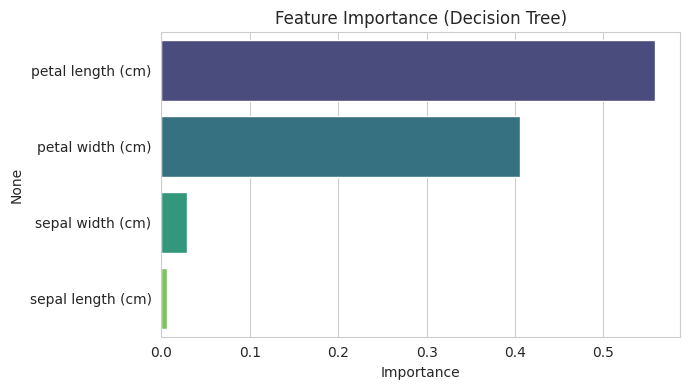

petal length (cm)    0.558568
petal width (cm)     0.406015
sepal width (cm)     0.029167
sepal length (cm)    0.006250
dtype: float64

In [13]:
importances = pd.Series(dt.feature_importances_, index=iris.feature_names).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=150)
plt.show()

importances

## 10. Conclusion

- All three models performed well on this dataset due to its clean, well-separated classes.
- **Petal length and petal width** were the most important features for classification — this matches the pairplot, where these two features show the clearest separation between species.
- The best-performing model achieved strong accuracy on the test set (see results table above).
- Sepal measurements were less useful for distinguishing species, especially between versicolor and virginica.

**Tools used:** Python, pandas, scikit-learn, matplotlib, seaborn